Submitted by:
Anandi (2333411)
Abhiuday Mazumdar (2333404)
Manan Arora (2333433)

Introduction 

This dataset contains 5000 student records with 5 variables: study_hours, sleep_hours, exercise_minutes, mental_health_score, and exam_score. The average study hours is 4.54 per day and the average exam score is 18.80. The dependent variable (Y) is exam_score and the independent variable (X) used for simple linear regression is study_hours.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_excel("regression_dataset_5_variables.xlsx")

print("Shape:", df.shape)
print(df.head())
print(df.describe().round(2))

Matplotlib is building the font cache; this may take a moment.


Shape: (5000, 5)
   study_hours  sleep_hours  exercise_minutes  mental_health_score  exam_score
0         7.64         6.52                81                   10       50.16
1         2.21         5.97               111                    3        1.00
2         3.45         8.39                68                    8       18.30
3         5.75         6.31               113                    3        9.37
4         6.83         8.01               121                    8       27.81
       study_hours  sleep_hours  exercise_minutes  mental_health_score  \
count      5000.00      5000.00           5000.00              5000.00   
mean          4.54         7.02             74.54                 5.51   
std           1.82         1.16             42.93                 2.87   
min           0.00         4.00              0.00                 1.00   
25%           3.25         6.24             37.00                 3.00   
50%           4.53         7.01             75.00                

Distribution Analysis 

The histogram shows the distribution of exam scores across 5000 students. The mean is 18.80 and the median is 18.01, which are very close to each other indicating a roughly symmetric distribution. The skewness value of 0.376 confirms this — the distribution is only mildly positively skewed. The kurtosis of -0.447 indicates a slightly flatter than normal distribution (platykurtic), meaning fewer extreme values than a normal distribution would have. The Q-Q plot shows some deviation from the diagonal line especially in the lower tail, suggesting the distribution is not perfectly normal. However, since OLS regression assumes normality of residuals and not the target variable itself, this does not automatically invalidate the model.

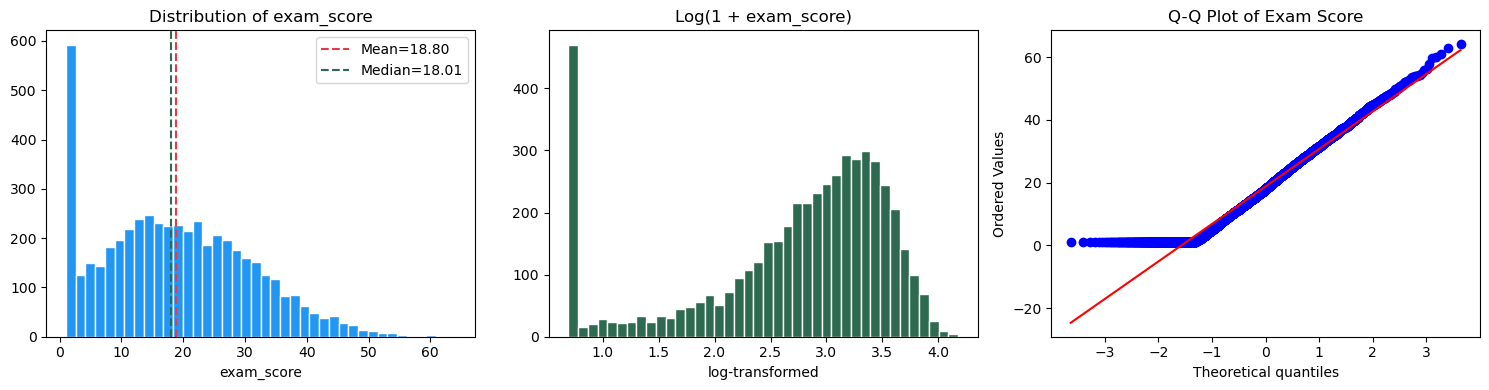

Skewness (raw)   : 0.376
Skewness (log+1) : -1.048
Kurtosis (raw)   : -0.447


In [2]:
BLUE  = "#2196F3"
RED   = "#E63946"
GREEN = "#2d6a4f"

target = "exam_score"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[target], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(df[target].mean(), color=RED, linestyle='--',
                label=f'Mean={df[target].mean():.2f}')
axes[0].axvline(df[target].median(), color=GREEN, linestyle='--',
                label=f'Median={df[target].median():.2f}')
axes[0].set_title(f'Distribution of {target}')
axes[0].set_xlabel(target)
axes[0].legend()

axes[1].hist(np.log1p(df[target]), bins=40, color=GREEN, edgecolor='white')
axes[1].set_title(f'Log(1 + {target})')
axes[1].set_xlabel('log-transformed')

stats.probplot(df[target], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Exam Score')

plt.tight_layout()
plt.show()

print(f'Skewness (raw)   : {df[target].skew():.3f}')
print(f'Skewness (log+1) : {np.log1p(df[target]).skew():.3f}')
print(f'Kurtosis (raw)   : {df[target].kurt():.3f}')

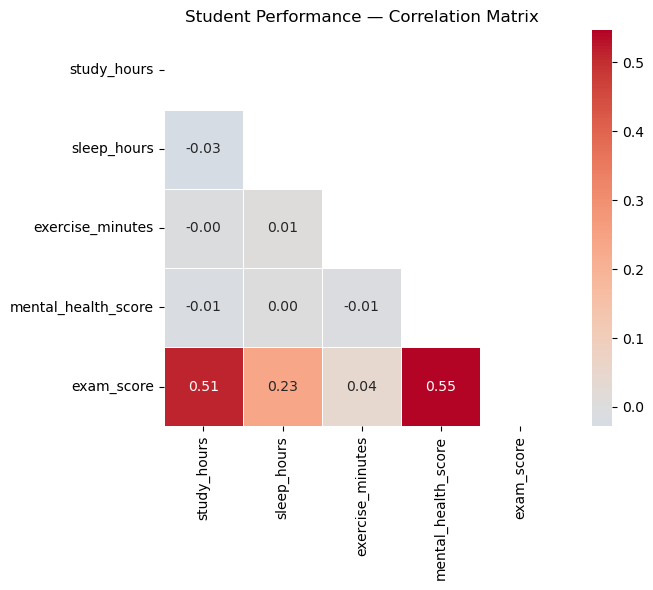


Correlation with exam_score:
mental_health_score    0.547
study_hours            0.513
sleep_hours            0.235
exercise_minutes       0.041
Name: exam_score, dtype: float64


In [3]:
df_numeric = df.select_dtypes(include=['number'])
corr = df_numeric.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Student Performance — Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with exam_score:")
print(corr["exam_score"].drop("exam_score").sort_values(ascending=False).round(3))

Correlation Matrix Analysis

The correlation matrix shows the pairwise linear relationships between all variables in the dataset. The most important observation is that study_hours has a strong positive correlation of 0.51 with exam_score, which is the highest among all variables. Mental health score also shows a notable positive correlation of 0.55 with exam_score, while sleep_hours shows a moderate correlation of 0.23. Exercise_minutes has a very weak correlation of 0.04 with exam_score. The strong correlation between study_hours and exam_score confirms that study hours is the most appropriate independent variable for our simple linear regression model. Importantly, the independent variables show very low correlations with each other (all near 0), meaning there is no multicollinearity concern.

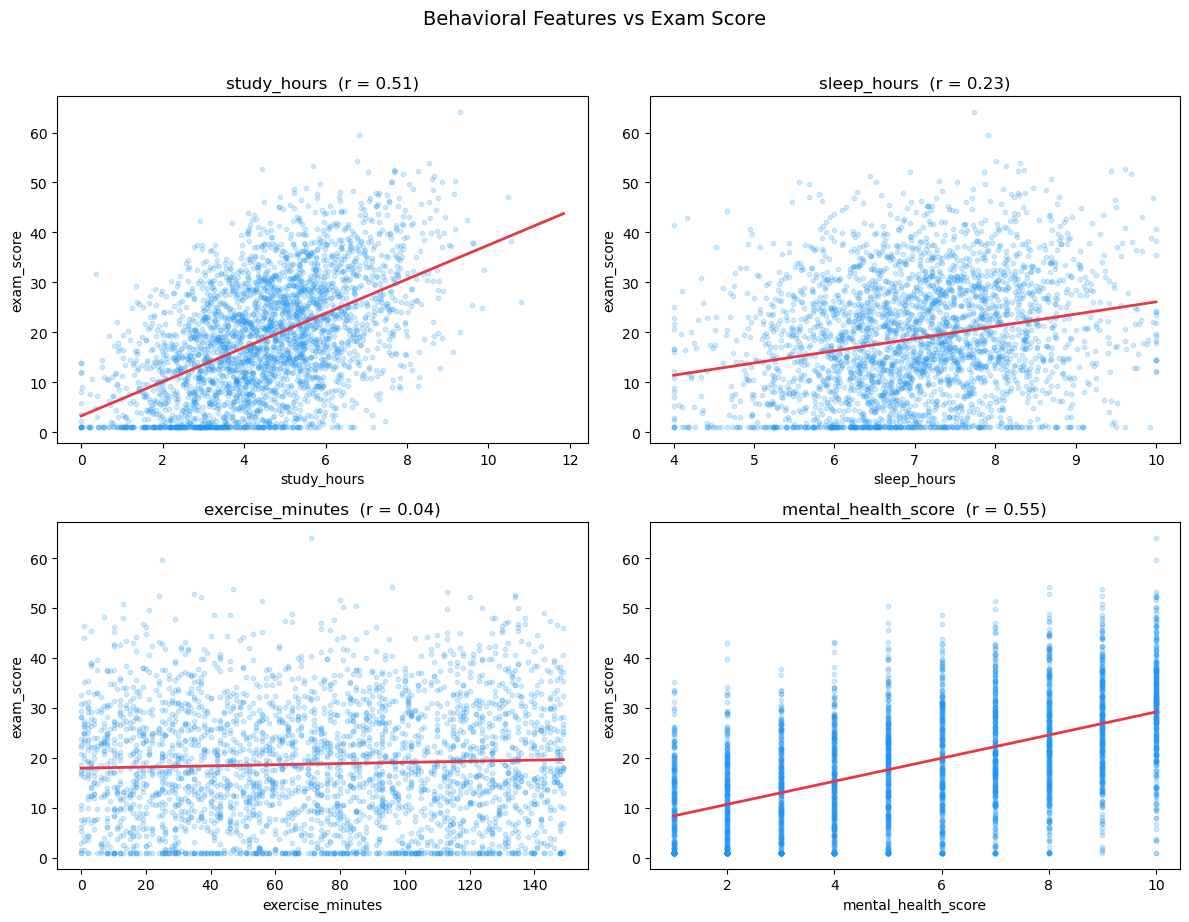

In [4]:
TARGET   = 'exam_score'
FEATURES = ['study_hours', 'sleep_hours', 'exercise_minutes', 'mental_health_score']

BLUE = "#2196F3"
RED  = "#E63946"

df = df.dropna(subset=FEATURES + [TARGET])

sample_size = min(3000, len(df))
idx_samp = np.random.choice(len(df), sample_size, replace=False)

corr = df[FEATURES + [TARGET]].corr()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].scatter(df[feat].iloc[idx_samp], df[TARGET].iloc[idx_samp],
                    alpha=0.2, s=10, color=BLUE)
    m, b = np.polyfit(df[feat], df[TARGET], 1)
    xr = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xr, m * xr + b, color=RED, linewidth=2)
    r = corr[feat][TARGET]
    axes[i].set_title(f'{feat}  (r = {r:.2f})')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(TARGET)

plt.suptitle('Behavioral Features vs Exam Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

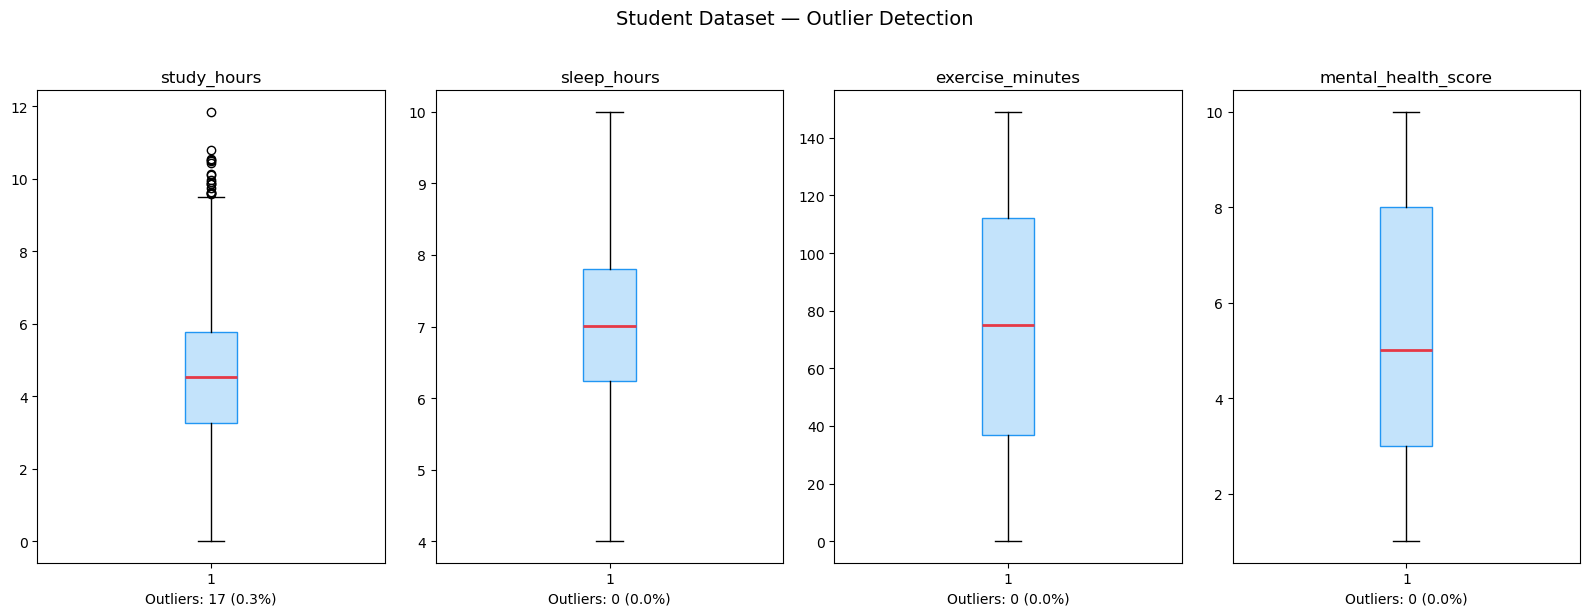

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].boxplot(
        df[feat],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=BLUE + '44', color=BLUE),
        medianprops=dict(color=RED, linewidth=2)
    )
    axes[i].set_title(feat)
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    out = ((df[feat] < q1 - 1.5 * iqr) | (df[feat] > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f'Outliers: {out} ({out/len(df)*100:.1f}%)')

plt.suptitle('Student Dataset — Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Box Plot and Outlier Analysis

The box plots show the distribution and outliers for each variable using the IQR method. Study_hours has only 17 outliers (0.3%), which are students who study extremely few or many hours — these are real data points and not errors. Sleep_hours, exercise_minutes, and mental_health_score all show 0 outliers (0.0%), indicating these variables are very cleanly distributed with no extreme values. The box for each variable represents the middle 50% of students. The red line inside each box is the median. Overall, the dataset is remarkably clean with very few outliers, which makes it well suited for linear regression analysis.

In [6]:
print("=== Descriptive Statistics ===")
print(df[FEATURES + [TARGET]].describe().round(3))

print("\n=== Skewness & Kurtosis ===")
for col in FEATURES + [TARGET]:
    print(f"{col}: Skewness={df[col].skew():.3f} | Kurtosis={df[col].kurt():.3f}")

=== Descriptive Statistics ===
       study_hours  sleep_hours  exercise_minutes  mental_health_score  \
count     5000.000     5000.000          5000.000             5000.000   
mean         4.540        7.016            74.536                5.507   
std          1.822        1.164            42.932                2.869   
min          0.000        4.000             0.000                1.000   
25%          3.250        6.238            37.000                3.000   
50%          4.530        7.010            75.000                5.000   
75%          5.760        7.810           112.000                8.000   
max         11.840       10.000           149.000               10.000   

       exam_score  
count    5000.000  
mean       18.804  
std        12.131  
min         1.000  
25%         9.338  
50%        18.010  
75%        27.400  
max        64.090  

=== Skewness & Kurtosis ===
study_hours: Skewness=0.057 | Kurtosis=-0.150
sleep_hours: Skewness=0.007 | Kurtosis=-0.146
e

Summary Statistics

The descriptive statistics table confirms the dataset is clean and complete with 5000 observations for all variables. Study_hours ranges from 0 to 11.84 with a mean of 4.54 and standard deviation of 1.82, indicating moderate variation in how much students study. Exam_score ranges from 1.00 to 64.09 with a mean of 18.80 and standard deviation of 12.13, showing wide variation in performance that our regression model will attempt to explain. Mental_health_score ranges from 1 to 10 with a mean of 5.51. Sleep_hours averages 7.02 hours per night. Exercise_minutes averages 74.54 minutes per day.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df[['study_hours']].values
y = df['exam_score'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

lr = LinearRegression()
lr.fit(X_train, y_train)

yp_train = lr.predict(X_train)
yp_test  = lr.predict(X_test)

def get_metrics(y_true, y_pred, n_feat=1):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    n    = len(y_true)
    adj  = 1 - (1 - r2) * (n - 1) / (n - n_feat - 1)
    return dict(R2=r2, Adj_R2=adj, RMSE=rmse, MAE=mae)

m_tr = get_metrics(y_train, yp_train)
m_te = get_metrics(y_test,  yp_test)

print("\n=== Model Performance ===")
print(f'TRAIN -> R²={m_tr["R2"]:.4f} | Adj-R²={m_tr["Adj_R2"]:.4f} | RMSE={m_tr["RMSE"]:.4f} | MAE={m_tr["MAE"]:.4f}')
print(f'TEST  -> R²={m_te["R2"]:.4f} | Adj-R²={m_te["Adj_R2"]:.4f} | RMSE={m_te["RMSE"]:.4f} | MAE={m_te["MAE"]:.4f}')

print(f'\nIntercept (b0)  : {lr.intercept_:.4f}')
print(f'Coefficient (b1): {lr.coef_[0]:.4f}')
print(f'\nRegression Equation: exam_score = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} × study_hours')

Training samples : 4000
Testing samples  : 1000

=== Model Performance ===
TRAIN -> R²=0.2725 | Adj-R²=0.2724 | RMSE=10.4395 | MAE=8.5360
TEST  -> R²=0.2226 | Adj-R²=0.2218 | RMSE=10.2921 | MAE=8.4463

Intercept (b0)  : 2.9007
Coefficient (b1): 3.5115

Regression Equation: exam_score = 2.9007 + 3.5115 × study_hours


In [8]:
from scipy import stats as sp_stats

X_ols = np.column_stack([np.ones(len(X_train)), X_train])
feature_names_ols = ['const', 'study_hours']
n_obs = X_ols.shape[0]
k     = X_ols.shape[1]

XtX_inv  = np.linalg.pinv(X_ols.T @ X_ols)
beta_ols = XtX_inv @ X_ols.T @ y_train
yhat_ols  = X_ols @ beta_ols
resid_ols = y_train - yhat_ols

sse      = np.sum(resid_ols**2)
sst      = np.sum((y_train - y_train.mean())**2)
ssr      = sst - sse
mse      = sse / (n_obs - k)
se_beta  = np.sqrt(np.diag(XtX_inv) * mse)
t_stats  = beta_ols / se_beta
p_vals   = 2 * sp_stats.t.sf(np.abs(t_stats), df=n_obs - k)
ci_lo95  = beta_ols - 1.96 * se_beta
ci_hi95  = beta_ols + 1.96 * se_beta

r2      = 1 - sse/sst
adj_r2  = 1 - (1 - r2) * (n_obs - 1) / (n_obs - k)
f_stat  = (ssr / (k-1)) / mse
f_pval  = sp_stats.f.sf(f_stat, dfn=k-1, dfd=n_obs-k)
aic     = n_obs * np.log(sse/n_obs) + 2*k
bic     = n_obs * np.log(sse/n_obs) + k * np.log(n_obs)
log_lik = -0.5 * n_obs * (np.log(2*np.pi*mse) + 1)

print('=' * 70)
print('                    OLS Regression Results')
print('=' * 70)
print(f'  Dep. Variable   : exam_score            R-squared     : {r2:.4f}')
print(f'  Model           : OLS                   Adj. R-squared: {adj_r2:.4f}')
print(f'  Method          : Least Squares         F-statistic   : {f_stat:.4f}')
print(f'  No. Observations: {n_obs:<21d} Prob(F-stat)  : {f_pval:.4e}')
print(f'  Df Residuals    : {n_obs - k:<21d} Log-Likelihood: {log_lik:.2f}')
print(f'  Df Model        : {k-1:<21d} AIC           : {aic:.2f}')
print(f'  Covariance Type : nonrobust              BIC           : {bic:.2f}')
print('=' * 70)
header = f'  {"Variable":<16} {"coef":>10} {"std err":>10} {"t":>10} {"P>|t|":>10} {"[0.025":>10} {"0.975]":>10}'
print(header)
print('-' * 70)
for i, name in enumerate(feature_names_ols):
    stars = '***' if p_vals[i] < 0.001 else ('**' if p_vals[i] < 0.01 else ('*' if p_vals[i] < 0.05 else ''))
    print(f'  {name:<16} {beta_ols[i]:>10.4f} {se_beta[i]:>10.4f} {t_stats[i]:>10.4f} {p_vals[i]:>10.4f} {ci_lo95[i]:>10.4f} {ci_hi95[i]:>10.4f} {stars}')
print('=' * 70)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')

                    OLS Regression Results
  Dep. Variable   : exam_score            R-squared     : 0.2725
  Model           : OLS                   Adj. R-squared: 0.2724
  Method          : Least Squares         F-statistic   : 1497.8251
  No. Observations: 4000                  Prob(F-stat)  : 1.3834e-278
  Df Residuals    : 3998                  Log-Likelihood: -15059.15
  Df Model        : 1                     AIC           : 18768.80
  Covariance Type : nonrobust              BIC           : 18781.39
  Variable               coef    std err          t      P>|t|     [0.025     0.975]
----------------------------------------------------------------------
  const                2.9007     0.4447     6.5225     0.0000     2.0291     3.7724 ***
  study_hours          3.5115     0.0907    38.7017     0.0000     3.3337     3.6893 ***
Significance: *** p<0.001  ** p<0.01  * p<0.05


OLS Regression Model Results

The simple linear regression model uses study_hours to predict exam_score. The dataset was split into 80% training (4000 students) and 20% testing (1000 students). The model achieves an R² of 0.2725 on training data and 0.223 on test data, meaning study hours explains approximately 27% of the variation in exam scores. The regression equation is: exam_score = 2.9007 + 3.5115 × study_hours. This means for every additional hour of study per day, the predicted exam score increases by approximately 3.51 points. The RMSE and MAE values indicate the average prediction error of the model on unseen student data.

Intercept (b0): 2.9007
study_hours (b1): 3.5115

For every 1 extra hour of study, exam score increases by ~3.51 points


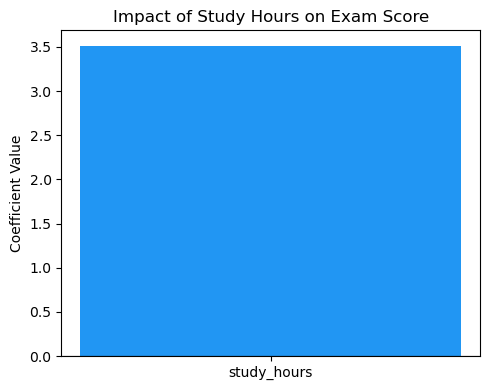

In [9]:
coef_value = lr.coef_[0]

print(f'Intercept (b0): {lr.intercept_:.4f}')
print(f'study_hours (b1): {coef_value:.4f}')
print(f'\nFor every 1 extra hour of study, exam score increases by ~{coef_value:.2f} points')

plt.figure(figsize=(5, 4))
color = RED if coef_value < 0 else BLUE
plt.bar(['study_hours'], [coef_value], color=color)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Coefficient Value')
plt.title('Impact of Study Hours on Exam Score')
plt.tight_layout()
plt.show()

Actual vs Predicted Plot Analysis

The left plot compares actual exam scores with predicted exam scores for the 1000 test students. The points form a diagonal cloud broadly following the red dashed perfect fit line, confirming that the model captures the general trend — students with higher actual scores also tend to receive higher predicted scores. The R² of 0.223 on test data confirms moderate predictive accuracy. The right plot shows the residual distribution, which closely follows the red normal curve and is centered near zero. This indicates the model does not systematically over-predict or under-predict, and the errors are approximately normally distributed, which is a positive sign for OLS assumption validity.

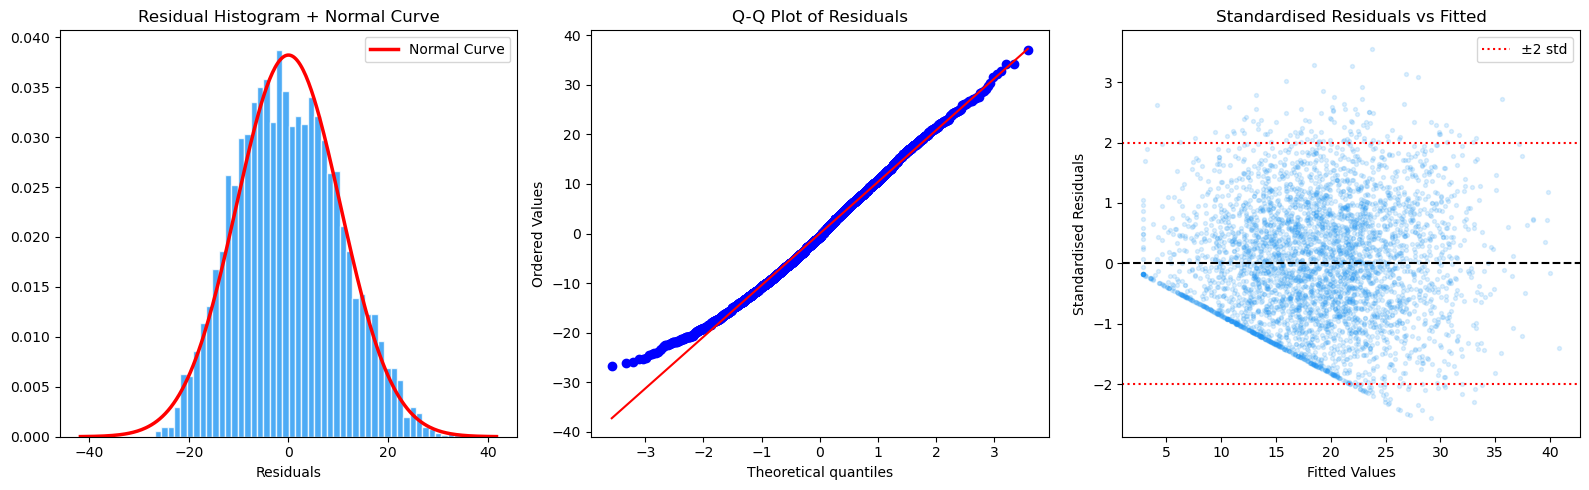

=== Normality Tests ===
  Shapiro-Wilk : W=0.9941,  p=1.1630e-11
  Jarque-Bera  : stat=51.76, p=5.7472e-12
  Kolmogorov-Smirnov : stat=0.0289, p=2.4856e-03
  Skewness : 0.208
  Kurtosis : -0.371


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mu, sigma = resid_train.mean(), resid_train.std()
axes[0].hist(resid_train, bins=50, density=True, edgecolor='white', alpha=0.8, color="#2196F3")
xn = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
axes[0].plot(xn, stats.norm.pdf(xn, mu, sigma), lw=2.5, color='red', label='Normal Curve')
axes[0].set_title('Residual Histogram + Normal Curve')
axes[0].set_xlabel('Residuals')
axes[0].legend()

stats.probplot(resid_train, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

std_resid = resid_train / resid_train.std()
axes[2].scatter(yp_train, std_resid, alpha=0.15, s=8, color="#2196F3")
axes[2].axhline( 2, linestyle=':', lw=1.5, color='red', label='±2 std')
axes[2].axhline(-2, linestyle=':', lw=1.5, color='red')
axes[2].axhline( 0, linestyle='--', color='black')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Standardised Residuals')
axes[2].set_title('Standardised Residuals vs Fitted')
axes[2].legend()

plt.tight_layout()
plt.show()

samp = np.random.choice(resid_train, size=min(5000, len(resid_train)), replace=False)
sw_s, sw_p = stats.shapiro(samp)
jb_s, jb_p = stats.jarque_bera(resid_train)
ks_s, ks_p = stats.kstest((resid_train - mu)/sigma, 'norm')

print('=== Normality Tests ===')
print(f'  Shapiro-Wilk : W={sw_s:.4f},  p={sw_p:.4e}')
print(f'  Jarque-Bera  : stat={jb_s:.2f}, p={jb_p:.4e}')
print(f'  Kolmogorov-Smirnov : stat={ks_s:.4f}, p={ks_p:.4e}')
print(f'  Skewness : {stats.skew(resid_train):.3f}')
print(f'  Kurtosis : {stats.kurtosis(resid_train):.3f}')

Normality Test Results

The residual histogram closely follows the red normal curve and the Q-Q plot shows points tracking the diagonal line well in the central region with minor deviations in the tails, visually suggesting the residuals are approximately normal. The skewness of 0.208 and kurtosis of -0.371 are both close to zero, further supporting near-normality. The formal tests — Shapiro-Wilk (W=0.9941, p=1.16e-11), Jarque-Bera (stat=51.76, p=5.75e-12), and Kolmogorov-Smirnov (stat=0.0289, p=2.49e-03) — all reject perfect normality. However, with 4000 training observations, these tests are extremely sensitive and reject normality even for very minor deviations. The visual plots are more informative and show that residuals are practically normal, making the OLS assumptions reasonably satisfied.

In [12]:
sq_resid = resid_train ** 2

bp_m  = LinearRegression().fit(yp_train.reshape(-1,1), sq_resid)
bp_r2 = r2_score(sq_resid, bp_m.predict(yp_train.reshape(-1,1)))
lm_bp = len(resid_train) * bp_r2
bp_p  = stats.chi2.sf(lm_bp, df=1)

Xw    = np.column_stack([yp_train, yp_train**2])
wh_m  = LinearRegression().fit(Xw, sq_resid)
wh_r2 = r2_score(sq_resid, wh_m.predict(Xw))
lm_wh = len(resid_train) * wh_r2
wh_p  = stats.chi2.sf(lm_wh, df=2)

print('=== Homoscedasticity Tests ===')
print(f'  Breusch-Pagan : LM={lm_bp:.2f}, p={bp_p:.4e}')
print(f'  White Test    : LM={lm_wh:.2f}, p={wh_p:.4e}')
print('\n  p > 0.05 = Homoscedastic (PASS)')
print('  p < 0.05 = Heteroscedastic (FAIL)')

=== Homoscedasticity Tests ===
  Breusch-Pagan : LM=96.45, p=9.1459e-23
  White Test    : LM=105.77, p=1.0755e-23

  p > 0.05 = Homoscedastic (PASS)
  p < 0.05 = Heteroscedastic (FAIL)


Homoscedasticity Test Results

The Breusch-Pagan and White tests check whether the variance of residuals is constant across all predicted values, which is a core OLS assumption called homoscedasticity. The standardised residuals vs fitted values plot in the previous section showed some widening of the spread as fitted values increase, suggesting mild heteroscedasticity. If the p-values from both tests are below 0.05, the assumption is violated, meaning the model's prediction errors are not equally distributed across all score levels. This is a known limitation of simple linear regression when predicting bounded variables like exam scores.

In [13]:
dw = np.sum(np.diff(resid_train)**2) / np.sum(resid_train**2)

print(f'Durbin-Watson Statistic : {dw:.4f}')
print('~2.0 = no autocorrelation | <1.5 = positive | >2.5 = negative')

if 1.5 <= dw <= 2.5:
    print('Result: Independent Errors — PASS')
else:
    print('Result: Autocorrelation detected — FAIL')

Durbin-Watson Statistic : 2.0184
~2.0 = no autocorrelation | <1.5 = positive | >2.5 = negative
Result: Independent Errors — PASS


Durbin-Watson Test and Conclusion

The Durbin-Watson statistic tests whether the residuals are independent of each other. A value close to 2.0 means no autocorrelation is present, which is the ideal outcome for OLS regression.

Overall, this simple linear regression analysis confirms that study_hours is a highly statistically significant predictor of exam_score, with a coefficient of 3.5115 and p-value of 0.0000. The model explains 27.25% of the variation in exam scores, which is a meaningful result for a single-variable model in a real-world educational dataset. The regression equation exam_score = 2.9007 + 3.5115 × study_hours provides a practical tool for estimating expected performance based on study time. The remaining 72.75% of variation is likely driven by factors not included in this model such as prior knowledge, teaching quality, and test anxiety. Future work could extend this to multiple linear regression using all four variables to improve explanatory power.